In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping


# Load the raw CSV file and do a quick first inspection.
# This helps confirm the number of rows/columns, sample records,
# and the data types before any preprocessing starts.
def load_data(file_path):
    data = pd.read_csv(file_path)
    print(data.shape)  # Show dataset size.
    print(data.head())  # Show a few sample rows.
    data.info()  # Print column names, dtypes, and non-null counts.
    return data


# Check whether any columns contain missing values.
# In this dataset, the expectation is that all columns are complete,
# but this function confirms that before moving forward.
def check_null_values(data):
    null_counts = data.isnull().sum()
    print("Null values in each column:")
    print(null_counts)


In [81]:
# Compare loan purpose with repayment status.
# This helps identify whether some loan purposes are more likely
# to end up in the not fully paid category.
def explore_purpose_vs_target(data):
    plt.figure(figsize=(12, 6))
    sns.countplot(x='purpose', hue='not.fully.paid', data=data)
    plt.title('Loan Purpose vs Not Fully Paid')
    plt.xticks(rotation=45)
    plt.show()


# Compare FICO score distribution across the two target classes.
# A boxplot is useful here because it shows spread, median, and outliers.
def explore_fico_vs_target(data):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='not.fully.paid', y='fico', data=data)
    plt.title('FICO Score vs Not Fully Paid')
    plt.show()


# Compare interest rate distribution across the two target classes.
# This helps check whether higher interest rates are associated
# with loans that were not fully paid.
def explore_int_rate_vs_target(data):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='not.fully.paid', y='int.rate', data=data)
    plt.title('Interest Rate vs Not Fully Paid')
    plt.show()


In [62]:
# Print the class distribution of the target column
# and plot it to see whether the dataset is imbalanced.
def check_target_distribution(data, target_column):
    target_counts = data[target_column].value_counts()
    print(f"Distribution of target variable '{target_column}':")
    print(target_counts)
    print(data[target_column].value_counts(normalize=True) * 100)

    sns.countplot(x=target_column, data=data)
    plt.title("Target Distribution")
    plt.show()


# Convert categorical columns into numeric columns using one-hot encoding.
# This is necessary because the deep learning model can only work with numeric input.
# In this dataset, 'purpose' is the main categorical column.
def encode_categorical_variables(data):
    categorical_cols = data.select_dtypes(include=['object']).columns
    print("Categorical columns:", list(categorical_cols))
    data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
    print(f"Encoded dataset shape: {data_encoded.shape}")
    return data_encoded


# Plot a correlation heatmap using only numeric columns.
# This helps visually identify which features move together.
def plot_correlation_heatmap(data):
    numeric_data = data.select_dtypes(include=['number'])
    plt.figure(figsize=(14, 10))
    sns.heatmap(numeric_data.corr(), annot=False, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()


In [82]:
# Plot histograms for the main numeric features.
# This gives a quick feel for the distribution of each important variable.
def perform_eda(data):
    numeric_cols = ["int.rate", "installment", "log.annual.inc", "dti", "fico",
                    "days.with.cr.line", "revol.bal", "revol.util",
                    "inq.last.6mths", "delinq.2yrs", "pub.rec"]

    data[numeric_cols].hist(figsize=(15, 10), bins=20)
    plt.tight_layout()
    plt.show()


# Drop one feature from each highly correlated pair.
# This reduces redundancy in the input features and can make the model cleaner.
def drop_highly_correlated_features(data, threshold=0.8):
    corr_matrix = data.select_dtypes(include=['number']).corr().abs()

    # Keep only the upper triangle so each pair is checked once.
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Collect columns whose correlation with another feature is above the threshold.
    to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]
    print(f"Highly correlated features to drop: {to_drop}")

    data_dropped = data.drop(columns=to_drop)
    print(f"Dataset shape after dropping highly correlated features: {data_dropped.shape}")
    return data_dropped


In [83]:
# Split the data into input features (X) and target (y),
# then create training and testing sets.
# The test set is kept separate so final evaluation is done on unseen data.
def create_train_test_split(data, target_column):
    X = data.drop(target_column, axis=1)
    y = data[target_column]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Training set shape: {X_train.shape}, {y_train.shape}")
    print(f"Testing set shape: {X_test.shape}, {y_test.shape}")
    return X_train, X_test, y_train, y_test


# Balance only the training data using random oversampling.
# This is important because the target classes are imbalanced.
# The test set is intentionally left untouched for fair evaluation.
def balance_training_data(X_train, y_train):
    ros = RandomOverSampler(random_state=42)
    X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

    print("Before balancing:")
    print(y_train.value_counts())

    print("\nAfter balancing:")
    print(pd.Series(y_train_resampled).value_counts())
    return X_train_resampled, y_train_resampled


# Plot the target distribution after balancing the training set.
def plot_balanced_target_distribution(y_train_resampled):
    sns.countplot(x=y_train_resampled)
    plt.title("Balanced Target Distribution")
    plt.show()


In [84]:
# Standardize the feature values so they are on a similar scale.
# This helps the neural network train more smoothly.
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled


# Build and train a simple deep learning model for binary classification.
# The final sigmoid layer outputs the probability of the positive class.
def build_and_train_model(X_train_scaled, y_train_resampled):
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),  # Input size equals number of features.
        Dense(64, activation='relu'),
        Dropout(0.3),  # Dropout helps reduce overfitting.
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    # Binary crossentropy is the correct loss for a two-class problem.
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Stop early if validation loss stops improving.
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_scaled,
        y_train_resampled,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1
    )

    return model, history


# Evaluate the model on the untouched test set.
# This includes the confusion matrix, classification report, ROC-AUC,
# and the ROC curve.
def evaluate_model(model, X_test_scaled, y_test):
    y_pred_prob = model.predict(X_test_scaled).flatten()  # Predicted probabilities.
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to class labels.

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print(f"ROC AUC Score: {roc_auc:.4f}")

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()


(9578, 14)
   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0            0 

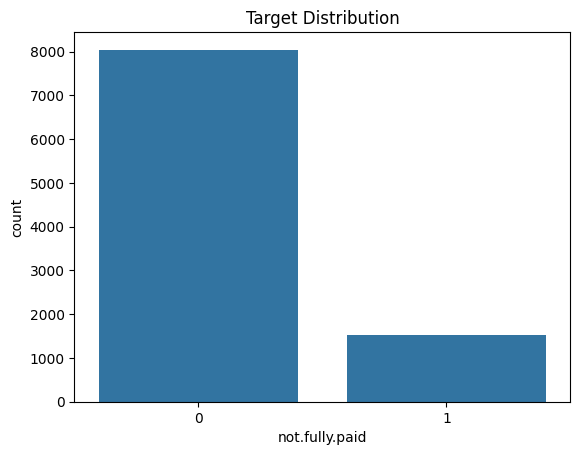

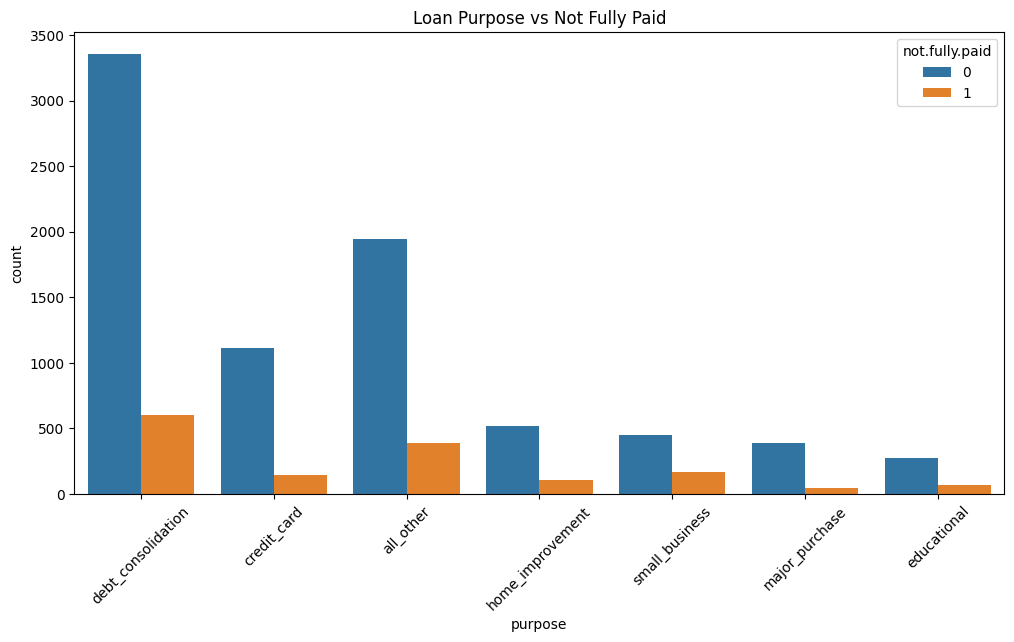

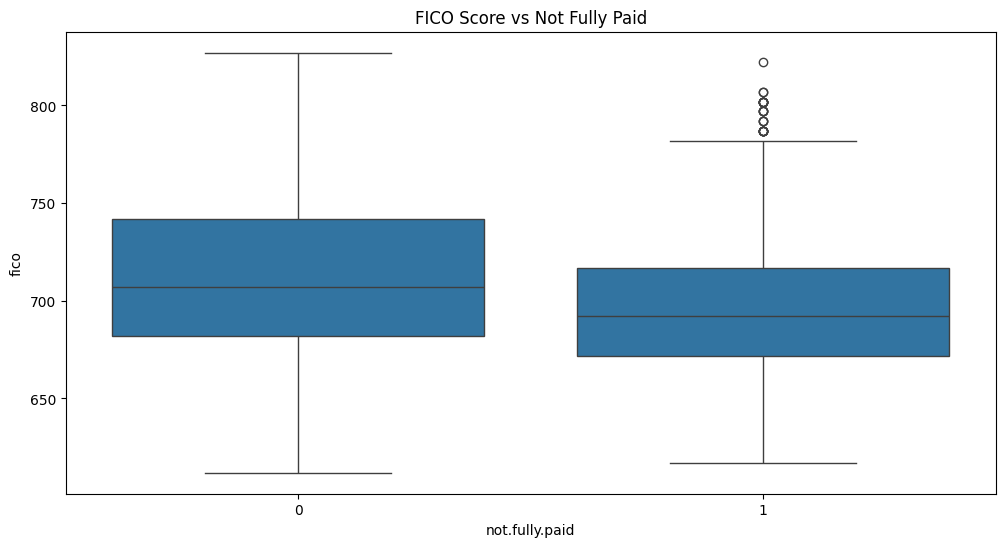

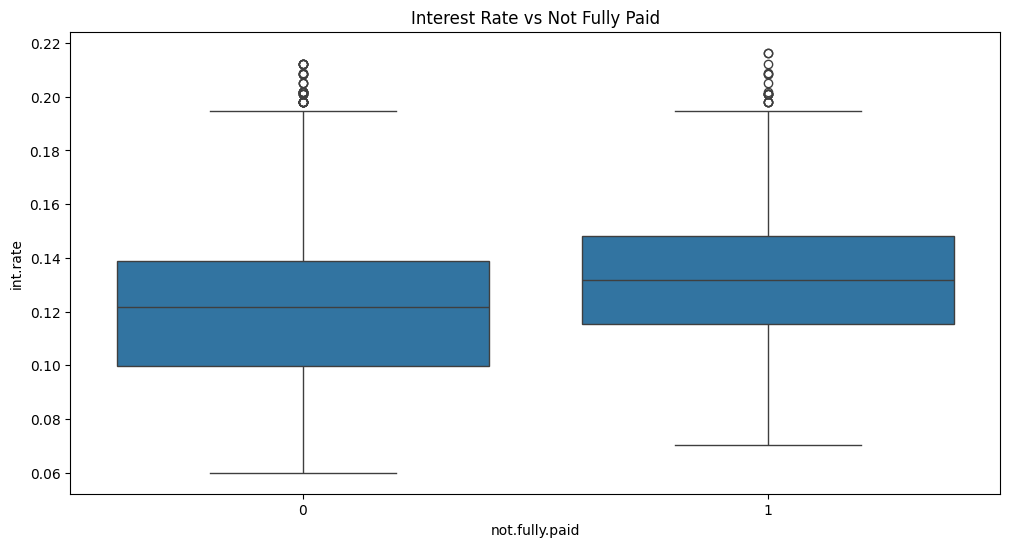

Categorical columns: ['purpose']
Encoded dataset shape: (9578, 19)


/var/folders/0g/q0gbscdx7fs0zbm0zxtjhn700000gn/T/ipykernel_80178/2931215794.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object']).columns


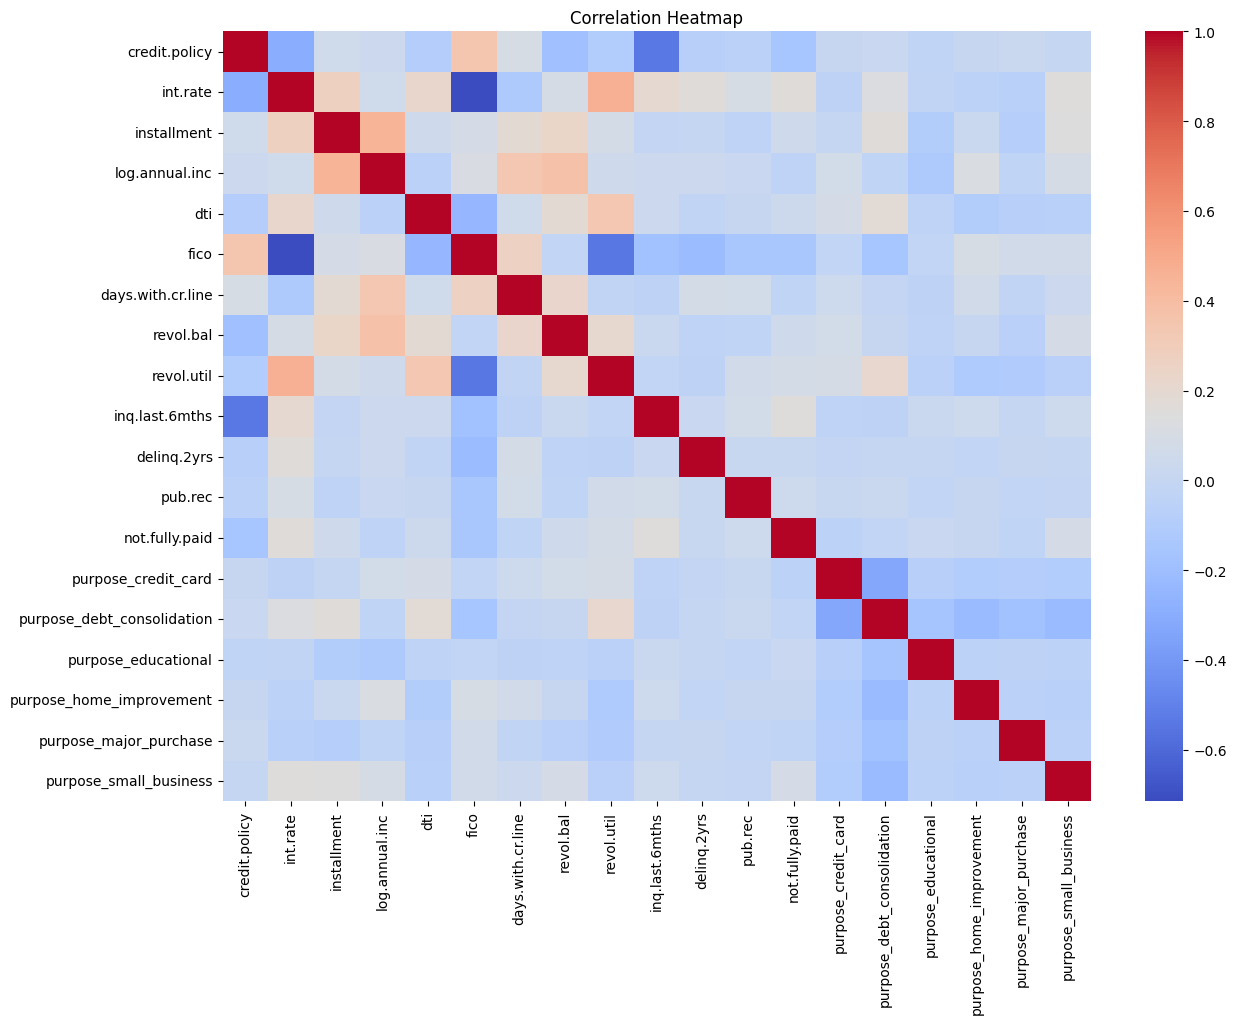

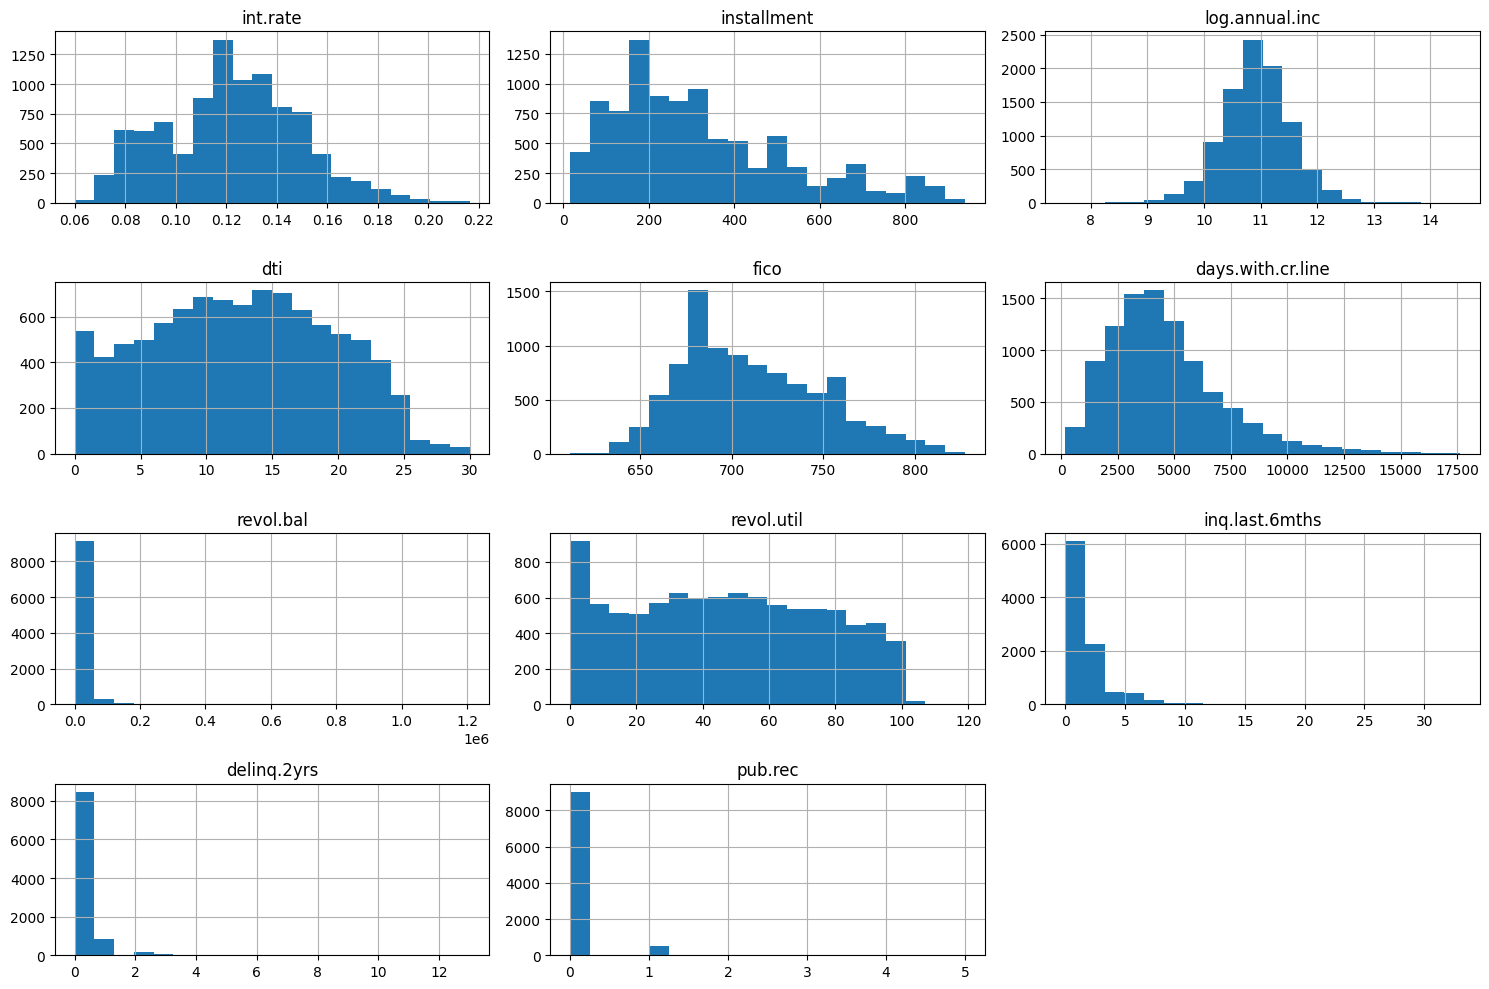

Highly correlated features to drop: []
Dataset shape after dropping highly correlated features: (9578, 19)
Training set shape: (7662, 18), (7662,)
Testing set shape: (1916, 18), (1916,)
Before balancing:
not.fully.paid
0    6434
1    1228
Name: count, dtype: int64

After balancing:
not.fully.paid
0    6434
1    6434
Name: count, dtype: int64


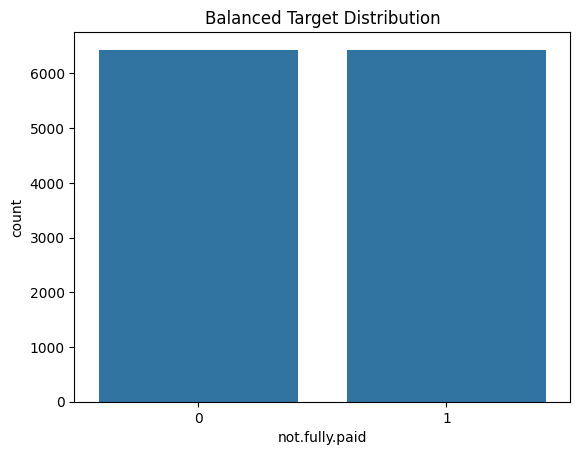

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step - accuracy: 0.6364 - loss: 0.6384 - val_accuracy: 0.4219 - val_loss: 0.8201
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.6605 - loss: 0.6158 - val_accuracy: 0.3566 - val_loss: 0.8845
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.6666 - loss: 0.6125 - val_accuracy: 0.3376 - val_loss: 0.8852
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.6663 - loss: 0.6103 - val_accuracy: 0.3730 - val_loss: 0.8540
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - accuracy: 0.6712 - loss: 0.6057 - val_accuracy: 0.3411 - val_loss: 0.8661
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - accuracy: 0.6739 - loss: 0.6013 - val_accuracy: 0.3741 - val_loss: 0.8384
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1611
           1       0.32      0.44      0.37    

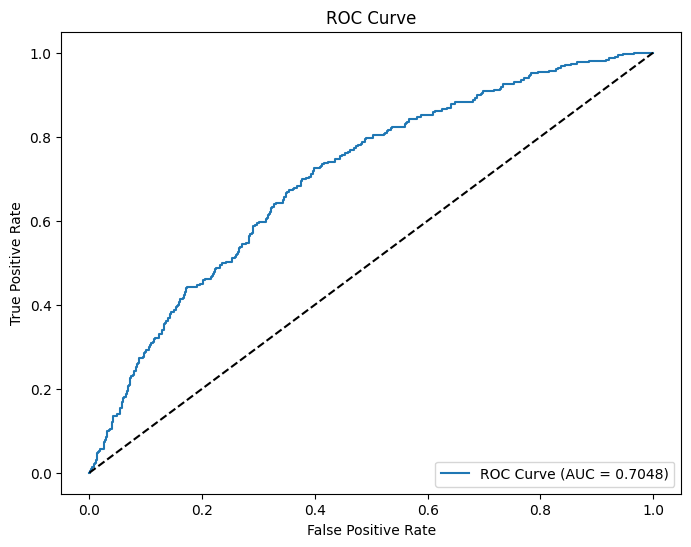

In [86]:
# Run the full workflow from raw data to final model evaluation.
def main():
    # Load the dataset and inspect its structure.
    data = load_data("lending_loan_data.csv")

    # Confirm there are no missing values.
    check_null_values(data)

    # Understand the target variable and visualize its imbalance.
    check_target_distribution(data, "not.fully.paid")

    # Perform EDA on the raw data before encoding.
    explore_purpose_vs_target(data)
    explore_fico_vs_target(data)
    explore_int_rate_vs_target(data)

    # Encode categorical variables so all features become numeric.
    data_encoded = encode_categorical_variables(data)

    # Explore numeric distributions and feature relationships after encoding.
    plot_correlation_heatmap(data_encoded)
    perform_eda(data_encoded)

    # Remove highly correlated features to reduce redundancy.
    data_dropped = drop_highly_correlated_features(data_encoded)

    # Split into train and test sets.
    X_train, X_test, y_train, y_test = create_train_test_split(data_dropped, "not.fully.paid")

    # Balance only the training data.
    X_train_balanced, y_train_balanced = balance_training_data(X_train, y_train)
    plot_balanced_target_distribution(y_train_balanced)

    # Scale features before training the neural network.
    X_train_scaled, X_test_scaled = scale_features(X_train_balanced, X_test)

    # Build, train, and evaluate the model.
    model, history = build_and_train_model(X_train_scaled, y_train_balanced)
    evaluate_model(model, X_test_scaled, y_test)


main()
